In [97]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import pickle

In [72]:
df =  pd.read_csv("segmentation data.csv")
df.head(10)

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1
5,100000006,0,0,35,1,144848,0,0
6,100000007,0,0,53,1,156495,1,1
7,100000008,0,0,35,1,193621,2,1
8,100000009,0,1,61,2,151591,0,0
9,100000010,0,1,28,1,174646,2,0


In [73]:
df.describe()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


array([[<Axes: title={'center': 'ID'}>, <Axes: title={'center': 'Sex'}>,
        <Axes: title={'center': 'Marital status'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Education'}>,
        <Axes: title={'center': 'Income'}>],
       [<Axes: title={'center': 'Occupation'}>,
        <Axes: title={'center': 'Settlement size'}>, <Axes: >]],
      dtype=object)

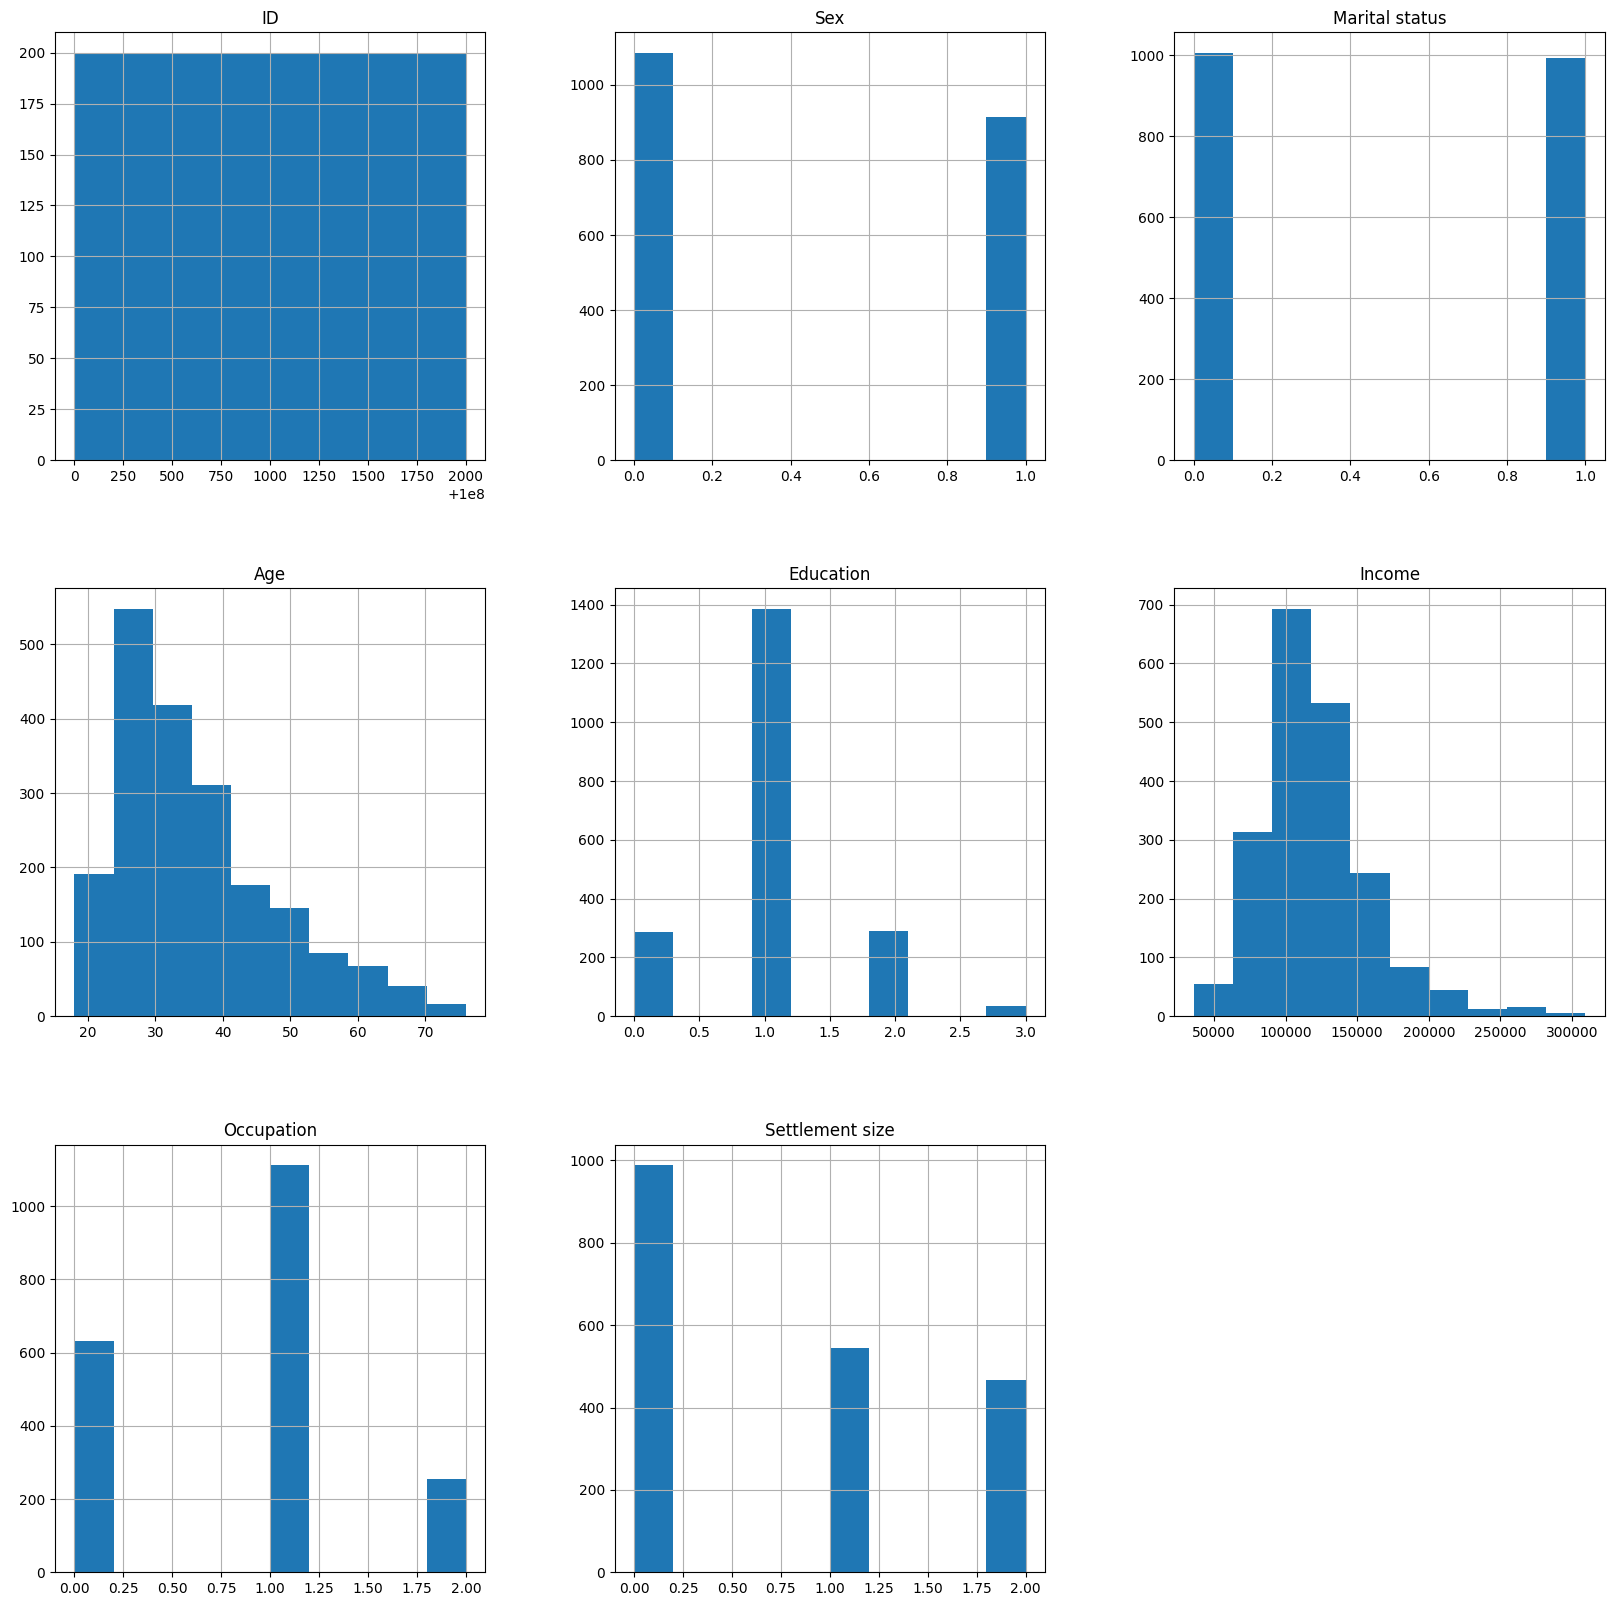

In [74]:
df.hist(figsize=(20,20))

In [75]:
df = df.drop("ID", axis=1)

In [76]:
df.shape

(2000, 7)

In [77]:
df.head()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2
2,0,0,49,1,89210,0,0
3,0,0,45,1,171565,1,1
4,0,0,53,1,149031,1,1


In [78]:
df.corr()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Sex,1.000000,0.566511,-0.182885,0.244838,-0.195146,-0.202491,-0.300803
Marital status,0.566511,1.000000,-0.213178,0.374017,-0.073528,-0.029490,-0.097041
Age,-0.182885,-0.213178,1.000000,0.654605,0.340610,0.108388,0.119751
Education,0.244838,0.374017,0.654605,1.000000,0.233459,0.064524,0.034732
Income,-0.195146,-0.073528,0.340610,0.233459,1.000000,0.680357,0.490881
Occupation,-0.202491,-0.029490,0.108388,0.064524,0.680357,1.000000,0.571795
Settlement size,-0.300803,-0.097041,0.119751,0.034732,0.490881,0.571795,1.000000


In [79]:
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Sex,1.000000,0.566511,-0.182885,0.244838,-0.195146,-0.202491,-0.300803
Marital status,0.566511,1.000000,-0.213178,0.374017,-0.073528,-0.029490,-0.097041
Age,-0.182885,-0.213178,1.000000,0.654605,0.340610,0.108388,0.119751
Education,0.244838,0.374017,0.654605,1.000000,0.233459,0.064524,0.034732
Income,-0.195146,-0.073528,0.340610,0.233459,1.000000,0.680357,0.490881
Occupation,-0.202491,-0.029490,0.108388,0.064524,0.680357,1.000000,0.571795
Settlement size,-0.300803,-0.097041,0.119751,0.034732,0.490881,0.571795,1.000000


In [80]:
list_of_pairs = set()

for i1 in df.columns:
    for i2 in df.columns:
        if i1 != i2:
            list_of_pairs.add(tuple(sorted([i1, i2])))

In [81]:
print(len(list_of_pairs))
list_of_pairs

21


{('Age', 'Education'),
 ('Age', 'Income'),
 ('Age', 'Marital status'),
 ('Age', 'Occupation'),
 ('Age', 'Settlement size'),
 ('Age', 'Sex'),
 ('Education', 'Income'),
 ('Education', 'Marital status'),
 ('Education', 'Occupation'),
 ('Education', 'Settlement size'),
 ('Education', 'Sex'),
 ('Income', 'Marital status'),
 ('Income', 'Occupation'),
 ('Income', 'Settlement size'),
 ('Income', 'Sex'),
 ('Marital status', 'Occupation'),
 ('Marital status', 'Settlement size'),
 ('Marital status', 'Sex'),
 ('Occupation', 'Settlement size'),
 ('Occupation', 'Sex'),
 ('Settlement size', 'Sex')}

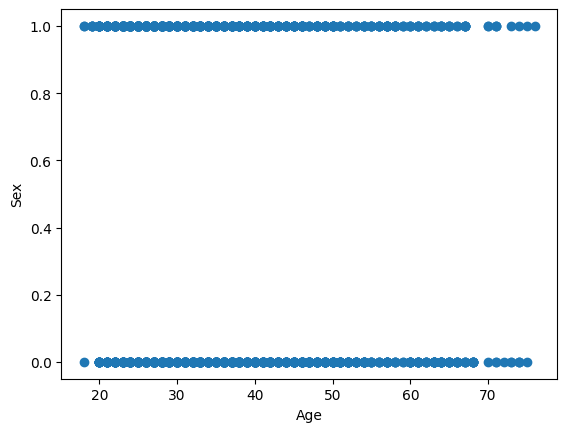

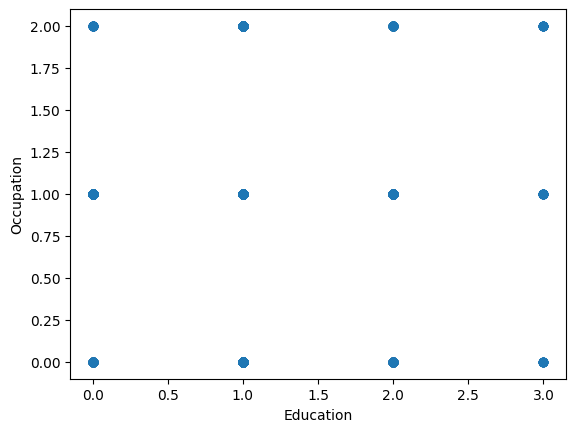

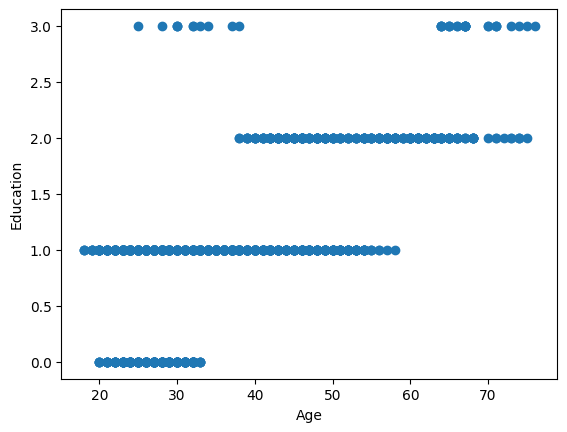

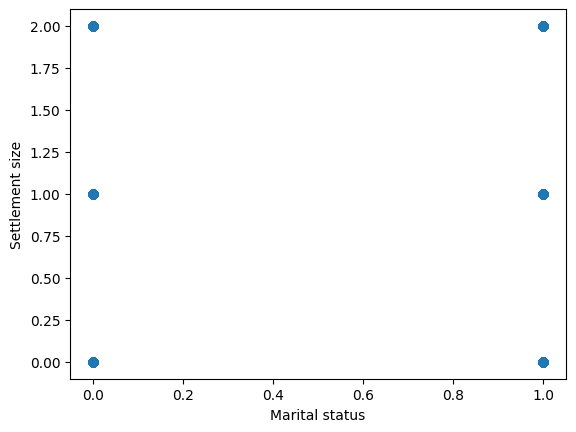

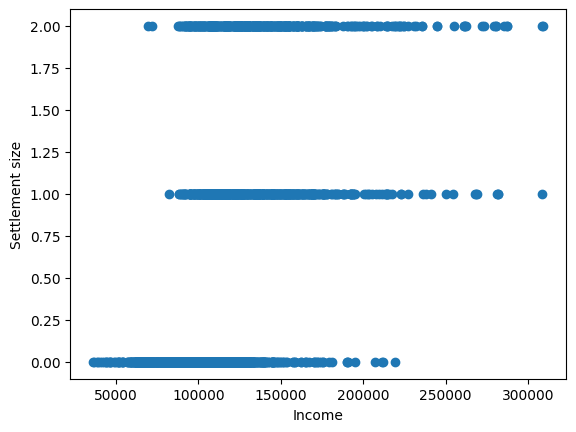

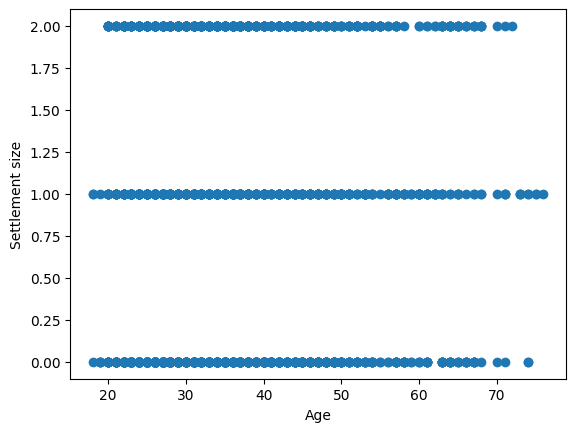

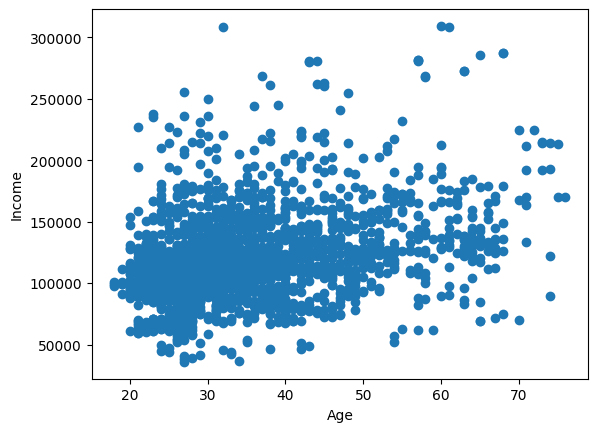

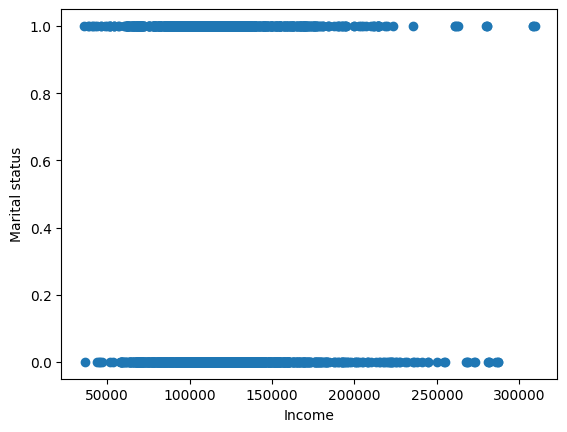

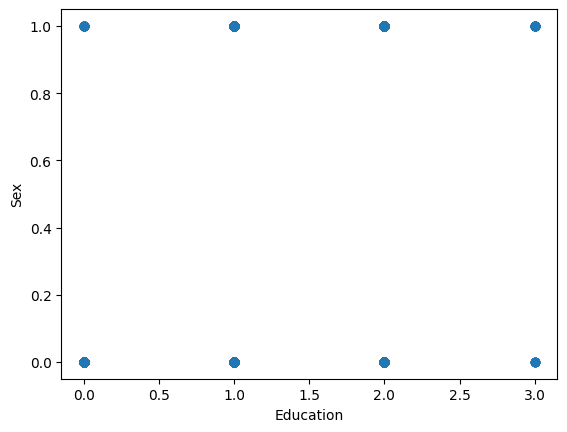

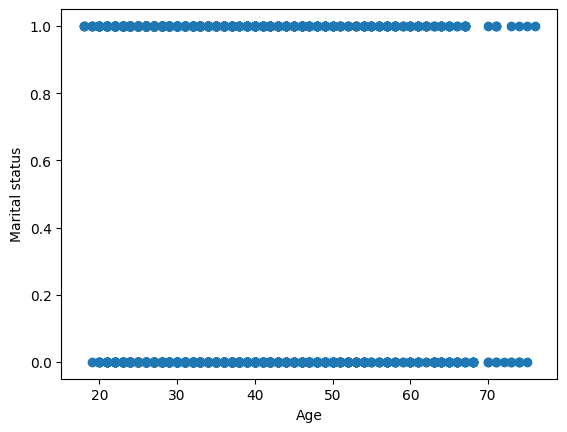

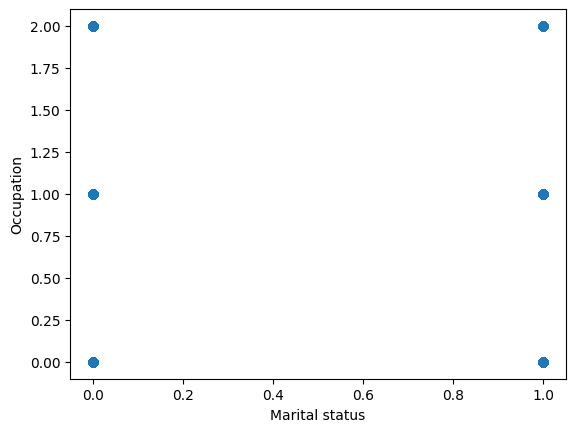

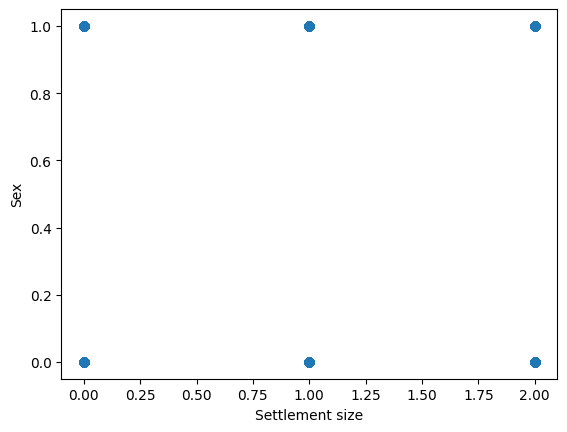

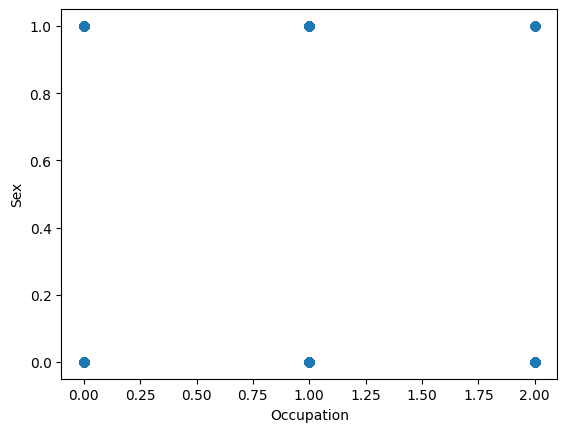

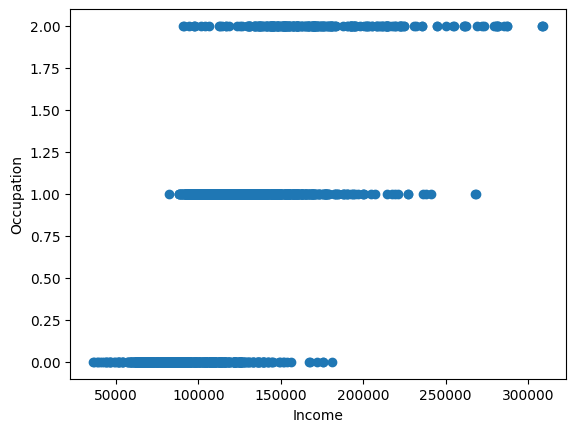

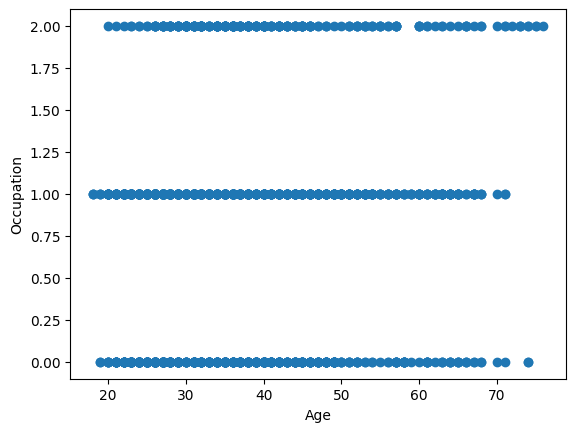

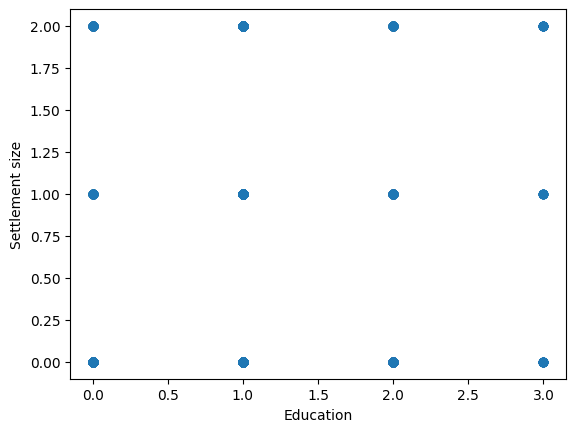

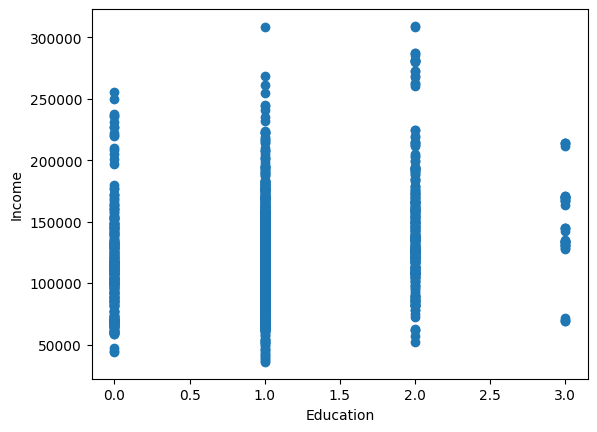

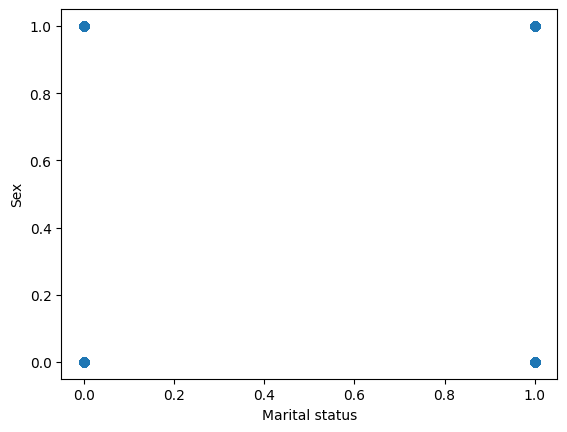

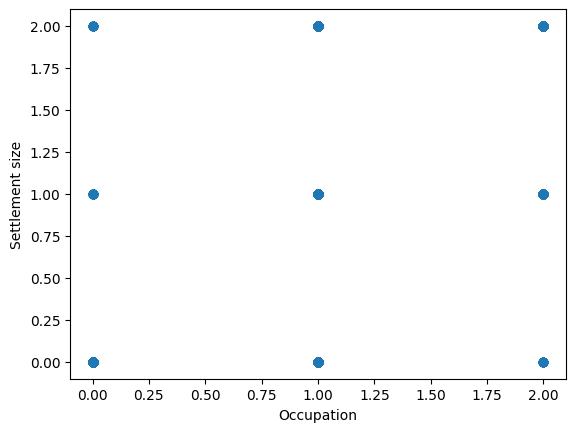

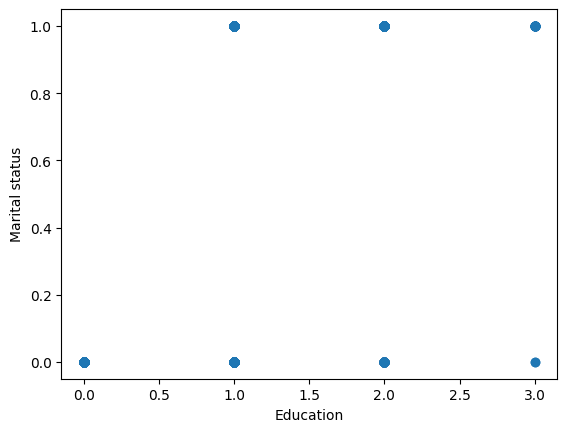

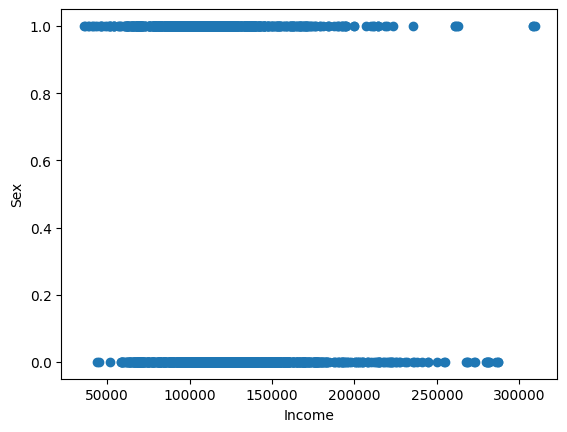

In [82]:
for f1, f2 in list_of_pairs:
    plt.scatter(df[f1], df[f2])
    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.show()

In [83]:
list_of_inertia = []

for k in range(1,21):
    km_all = KMeans(n_clusters=k)
    km_all.fit(df)
    list_of_inertia.append(km_all.inertia_)

print(list_of_inertia)

[2903113032648.644, 1214625235167.711, 675301319622.2971, 377736118087.5608, 248986947113.3495, 177205275150.17322, 146931181535.1416, 96916560466.5962, 79194207050.47421, 67274947622.01679, 56186559515.41749, 44712536757.37602, 40925863407.2352, 33915908021.81186, 31295752741.513054, 27293333018.51174, 24877487014.139256, 21173435518.564972, 20506167783.669468, 17032783068.561129]


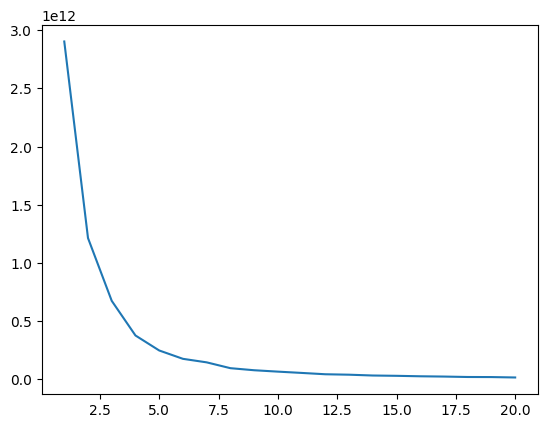

In [84]:
plt.plot(range(1,21), list_of_inertia)

In [85]:
for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(df)
    score = silhouette_score(df, labels)
    
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.583
k=3, silhouette score=0.513
k=4, silhouette score=0.543
k=5, silhouette score=0.541
k=6, silhouette score=0.542
k=7, silhouette score=0.519
k=8, silhouette score=0.541
k=9, silhouette score=0.533
k=10, silhouette score=0.535
k=11, silhouette score=0.540
k=12, silhouette score=0.542
k=13, silhouette score=0.535
k=14, silhouette score=0.530
k=15, silhouette score=0.531
k=16, silhouette score=0.534
k=17, silhouette score=0.529
k=18, silhouette score=0.525
k=19, silhouette score=0.523
k=20, silhouette score=0.518


In [86]:
def pca_transformation(data):
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(data)
    principal_df = pd.DataFrame(data = principal_components
             ,columns = ['principal component 1', 'principal component 2'])
    return principal_df

In [92]:
km = KMeans(n_clusters=6)
score = km.fit_predict(df)

In [93]:
score

array([0, 3, 2, ..., 4, 2, 4], shape=(2000,), dtype=int32)

In [94]:
df_pca = pca_transformation(df)

In [95]:
df_pca.head()

,principal component 1,principal component 2
0,3715.584256,30.714783
1,29818.579389,-17.036943
2,-31744.417466,16.420804
3,50610.581674,3.789668
4,28076.582639,14.143742


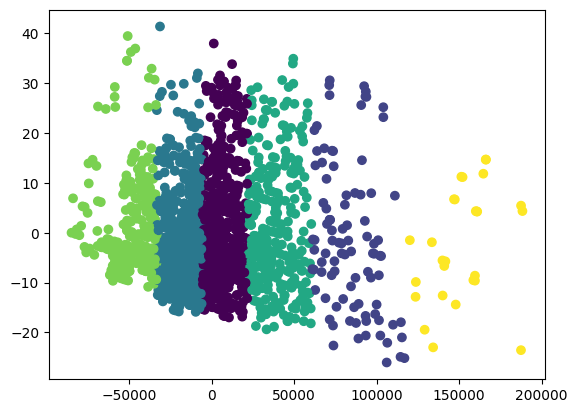

In [96]:
plt.scatter(df_pca["principal component 1"], df_pca["principal component 2"], c=km.labels_)

In [98]:
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(km, f)

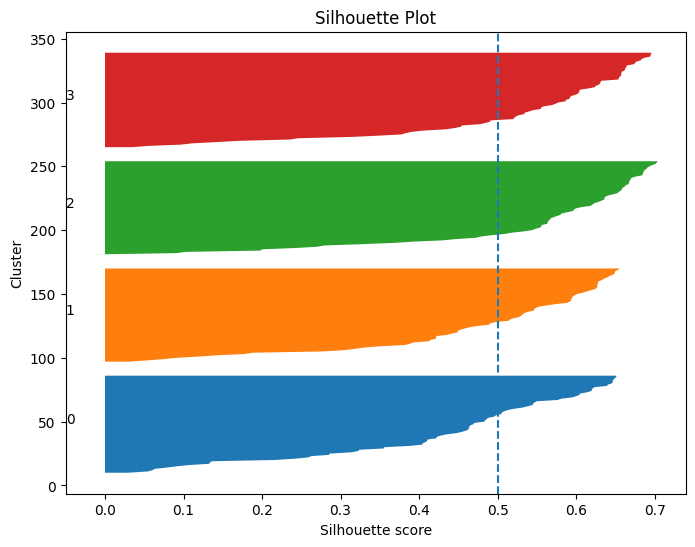

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# 1. Skapa data
X, _ = make_blobs(n_samples=300, centers=4, random_state=0)

# 2. Klustra
kmeans = KMeans(n_clusters=4, random_state=0)
labels = kmeans.fit_predict(X)

# 3. Beräkna silhouette values
silhouette_vals = silhouette_samples(X, labels)
avg_score = silhouette_score(X, labels)

# 4. Plot
y_lower = 10
plt.figure(figsize=(8, 6))

for i in range(4):
    cluster_vals = silhouette_vals[labels == i]
    cluster_vals.sort()
    
    size = cluster_vals.shape[0]
    y_upper = y_lower + size
    
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_vals
    )
    
    plt.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

# Genomsnittlig linje
plt.axvline(x=avg_score, linestyle="--")

plt.title("Silhouette Plot")
plt.xlabel("Silhouette score")
plt.ylabel("Cluster")
plt.show()

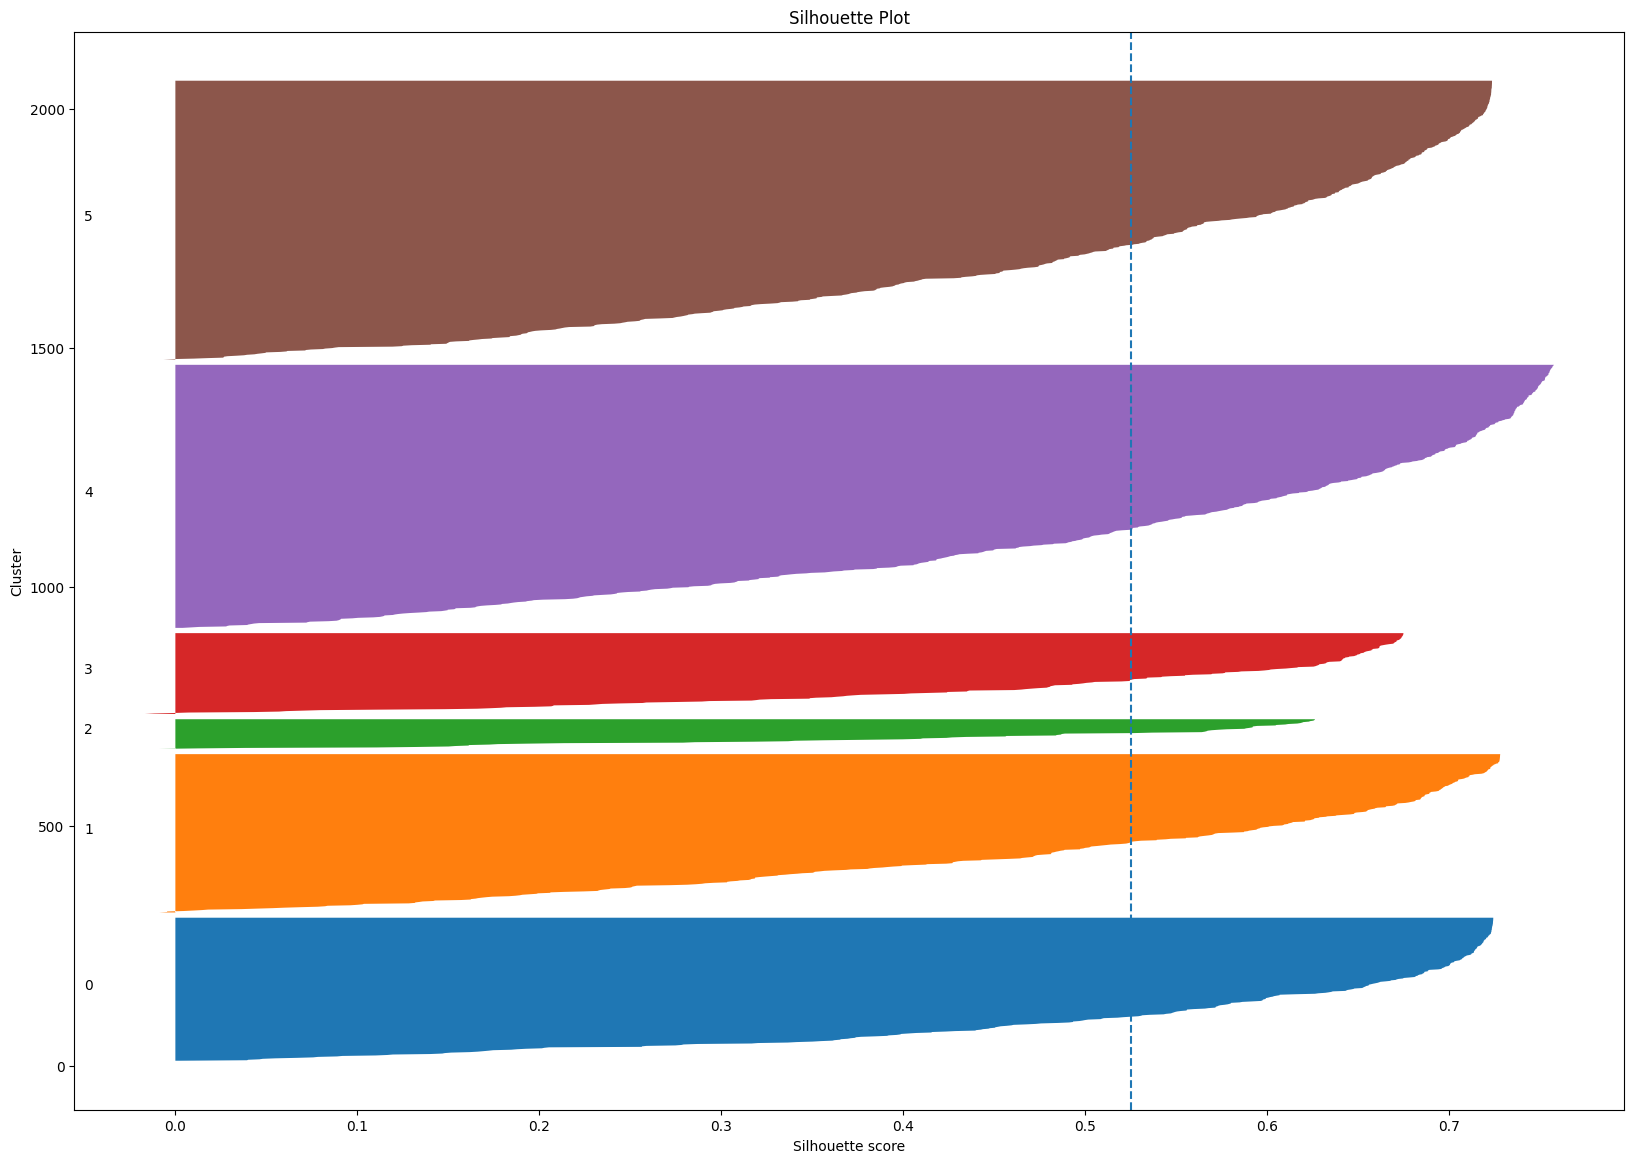

In [107]:
labels = km.fit_predict(df)

silhouette_vals = silhouette_samples(df, labels)
avg_score = silhouette_score(df, labels)
# 4. Plot
y_lower = 10
plt.figure(figsize=(20, 14))

for i in range(6):
    cluster_vals = silhouette_vals[labels == i]
    cluster_vals.sort()
    
    size = cluster_vals.shape[0]
    y_upper = y_lower + size
    
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_vals
    )
    
    plt.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

# Genomsnittlig linje
plt.axvline(x=avg_score, linestyle="--")

plt.title("Silhouette Plot")
plt.xlabel("Silhouette score")
plt.ylabel("Cluster")
plt.show()